In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [3]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    'authors_range': range(180),
    'input_shape': (60, 53, 1),
    'embedding_dim': 256,
    'epochs': 20,
    'seed': 42,
}

In [4]:
sys.path.insert(0, config['project_path'])

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 137.3 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=cff20e7c977d65be0bf41cd2f447dc862e0f73162a1340e18b158c49df5bebd2
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [ ]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [ ]:
dataset_path = f"{config['project_path']}/data/datasets/{config['dataset']}"

In [ ]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [ ]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [ ]:
!tar -xzf {dataset_path} -C ./

In [ ]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

In [13]:
from src.datasets import DataInitializer, PatchNormalizer, SubsetBuilder

In [14]:
normalizer = PatchNormalizer()

In [15]:
subset_builder = SubsetBuilder(
    loader=loader,
    data_normalizer=normalizer
)

In [16]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

05:35:13 - ZarrSerializer - INFO - ======================================================================
05:35:13 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
05:35:13 - ZarrSerializer - INFO - ======================================================================
05:35:13 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
05:35:13 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
05:35:13 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
05:35:13 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
05:35:13 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
05:35:13 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
05:35:13 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
05:35:13 - ZarrSerializer - INFO - ======================================================================
05:35:13 - ZarrSerializer - INF

Building subset dataset: 100%|██████████| 540/540 [01:14<00:00,  7.20it/s]


In [17]:
subset.keys()

dict_keys(['train', 'validation', 'test'])

In [18]:
from src.datasets import PairGenerator

In [19]:
train_pair_gen = PairGenerator(
    data=subset['train'].data,
    authors_ids=subset['train'].authors_ids,
    valid_authors=subset['train'].valid_authors,
    batch_size=64,
    shuffle=True,
    use_augmentation=True,
    seed=42
)

In [20]:
val_pair_gen = PairGenerator(
    data=subset['validation'].data,
    authors_ids=subset['validation'].authors_ids,
    valid_authors=subset['validation'].valid_authors,
    batch_size=32,
    use_augmentation=False,
    shuffle=False,
)

In [21]:
test_pair_gen = PairGenerator(
    data=subset['test'].data,
    authors_ids=subset['test'].authors_ids,
    valid_authors=subset['test'].valid_authors,
    batch_size=16,
    use_augmentation=False,
    shuffle=False,
)

In [22]:
len(train_pair_gen), len(val_pair_gen), len(test_pair_gen)

(8752, 2845, 1413)

In [23]:
logger.info(f"Train samples: {train_pair_gen.num_patches}")
logger.info(f"Validation samples: {val_pair_gen.num_patches}")
logger.info(f"Test samples: {test_pair_gen.num_patches}")
logger.info(f"Ratio: {train_pair_gen.num_patches / val_pair_gen.num_patches:.2f}")

INFO - Train samples: 560070
INFO - Validation samples: 91039
INFO - Test samples: 22594
INFO - Ratio: 6.15


In [24]:
logger.info(f"Train augmentation: {train_pair_gen.augmenter is not None}")
logger.info(f"Val augmentation: {val_pair_gen.augmenter is not None}")
logger.info(f"Test augmentation: {test_pair_gen.augmenter is not None}")

INFO - Train augmentation: True
INFO - Val augmentation: False
INFO - Test augmentation: False


In [25]:
train_stats = train_pair_gen.get_statistics()
logger.info(f"Train samples: {train_stats["total_patches"]}")
logger.info(f"Avg patches per author: {train_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {train_stats["min_patches"]}")
logger.info(f"Max patches per author: {train_stats["max_patches"]}")

INFO - Train samples: 560070
INFO - Avg patches per author: 3111.50
INFO - Min patches per author: 792
INFO - Max patches per author: 3269


In [26]:
val_stats = val_pair_gen.get_statistics()
logger.info(f"Val samples: {val_stats["total_patches"]}")
logger.info(f"Avg patches per author: {val_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {val_stats["min_patches"]}")
logger.info(f"Max patches per author: {val_stats["max_patches"]}")

INFO - Val samples: 91039
INFO - Avg patches per author: 505.77
INFO - Min patches per author: 143
INFO - Max patches per author: 533


In [27]:
test_stats = test_pair_gen.get_statistics()
logger.info(f"Val samples: {test_stats["total_patches"]}")
logger.info(f"Avg patches per author: {test_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {test_stats["min_patches"]}")
logger.info(f"Max patches per author: {test_stats["max_patches"]}")

INFO - Val samples: 22594
INFO - Avg patches per author: 125.52
INFO - Min patches per author: 92
INFO - Max patches per author: 143


In [28]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    DeepCNNBackbone,
    build_siamese_model,
    build_embedding_model,
    ContrastiveLoss,
    BinaryCrossEntropyDistance,
)
from src.models.training import ModelTrainer, get_default_callbacks
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [29]:
backbone = DeepCNNBackbone()

In [30]:
cnn_trainer = ModelTrainer(
    backbone=backbone,
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)

05:38:04 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
05:38:04 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
05:38:04 - siamese_cnn_trainer - INFO - Embedding dim: 256


In [31]:
cnn_trainer.build()

05:38:09 - siamese_cnn_trainer - INFO - Building models...
05:38:10 - siamese_cnn_trainer - INFO - Model built: siamese_model
05:38:10 - siamese_cnn_trainer - INFO - Total params: 3391296
05:38:10 - siamese_cnn_trainer - INFO - Trainable params: 3388544


In [32]:
cnn_trainer.embedding_model.summary()

Model: "siamese_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [33]:
cnn_trainer.siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_embedd… │ (None, 256)       │  3,391,296 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 2, 256)    │          0 │ siamese_cnn_embe… │
│                     │                   │            │ siamese_cnn_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [34]:
cnn_trainer.compile(loss=ContrastiveLoss(margin=1.0))

05:38:25 - siamese_cnn_trainer - INFO - Compiling model...
05:38:25 - siamese_cnn_trainer - INFO - Model compiled
05:38:25 - siamese_cnn_trainer - INFO -   - Optimizer: Adam
05:38:25 - siamese_cnn_trainer - INFO -   - Learning rate: 0.0001
05:38:25 - siamese_cnn_trainer - INFO -   - Loss: ContrastiveLoss
05:38:25 - siamese_cnn_trainer - INFO -   - Loss margin: 1.0


In [35]:
callbacks = get_default_callbacks(
    model_name="siamese_cnn",
    patience=4,
    reduce_lr_patience=2,
)

In [36]:
cnn_history = cnn_trainer.train(
    train_generator=train_pair_gen,
    val_generator=val_pair_gen,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

05:38:44 - siamese_cnn_trainer - INFO - Starting training for 20 epochs...
05:38:44 - siamese_cnn_trainer - INFO -   - Train batches: 8752
05:38:44 - siamese_cnn_trainer - INFO -   - Val batches: 2845
Epoch 1/20
8752/8752 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.2456
Epoch 1: val_loss improved from inf to 0.23614, saving model to checkpoints/siamese_cnn/best.keras
8752/8752 ━━━━━━━━━━━━━━━━━━━━ 1222s 138ms/step - loss: 0.2456 - val_loss: 0.2361 - learning_rate: 1.0000e-04
Epoch 2/20
8752/8752 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.2358
Epoch 2: val_loss improved from 0.23614 to 0.22658, saving model to checkpoints/siamese_cnn/best.keras
8752/8752 ━━━━━━━━━━━━━━━━━━━━ 1157s 132ms/step - loss: 0.2358 - val_loss: 0.2266 - learning_rate: 1.0000e-04
Epoch 3/20
8752/8752 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.2331
Epoch 3: val_loss improved from 0.22658 to 0.22433, saving model to checkpoints/siamese_cnn/best.keras
8752/8752 ━━━━━━━━━━━━━━━━━━━━ 1214s 139ms/step - loss: 0.233

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title="Training Loss"):
    loss = history.history["loss"]
    val_loss = history.history.get("val_loss")

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

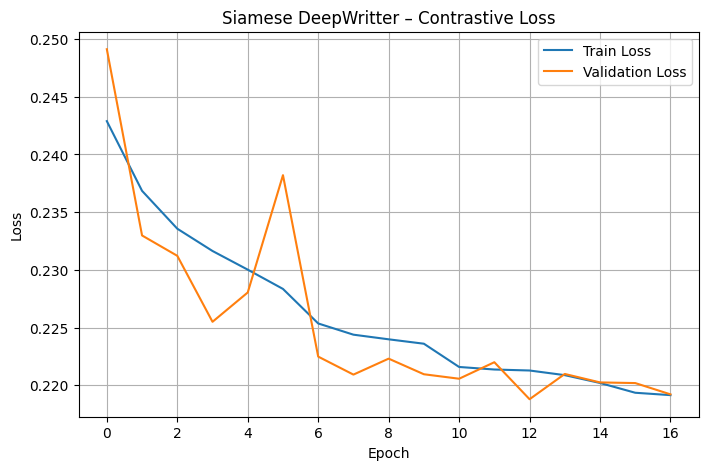

In [ ]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Contrastive Loss"
)

In [ ]:
cnn_trainer.save(f"./models/siamese_cnn_{current_time}.keras")

18:18:39 - siamese_cnn_trainer - INFO - Model saved to models/siamese_cnn_20260130-150119.keras


In [ ]:
cnn_trainer_new = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=(60, 53, 1),
    embedding_dim=256,
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)
cnn_trainer_new.build()

15:36:15 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
15:36:15 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
15:36:15 - siamese_cnn_trainer - INFO - Embedding dim: 256
15:36:15 - siamese_cnn_trainer - INFO - Building models...
15:36:16 - siamese_cnn_trainer - INFO - Model built: siamese_model
15:36:16 - siamese_cnn_trainer - INFO - Total params: 3391296
15:36:16 - siamese_cnn_trainer - INFO - Trainable params: 3388544


In [ ]:
cnn_trainer_new.siamese_model.load_weights(
    f"{config['project_path']}/data/datasets/experiments/models_100/siamese_cnn_20260130-150119.keras"
)

In [ ]:
cnn_evaluator = ModelEvaluator(
    model=cnn_trainer_new.siamese_model,
    model_name="siamese_cnn",
    embedding_model=cnn_trainer_new.embedding_model,
    log_dir=f"./logs_{current_time}"
)

In [ ]:
cnn_evaluator.model.summary()

In [ ]:
cnn_evaluator.embedding_model.summary()

In [ ]:
test_results = cnn_evaluator.evaluate(
    test_generator=test_pair_gen,
    distance_threshold=0.6
)

16:29:08 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn...
16:30:17 - siamese_cnn_evaluator - INFO - Evaluation completed:
16:30:17 - siamese_cnn_evaluator - INFO -   - Accuracy:  0.6268
16:30:17 - siamese_cnn_evaluator - INFO -   - AUC:       0.8227
16:30:17 - siamese_cnn_evaluator - INFO -   - Precision: 0.5737
16:30:17 - siamese_cnn_evaluator - INFO -   - Recall:    0.9879
16:30:17 - siamese_cnn_evaluator - INFO -   - F1-Score:  0.7258


INFO - Positive pairs - mean: 0.2927, std: 0.1172
INFO - Negative pairs - mean: 0.4839, std: 0.1640


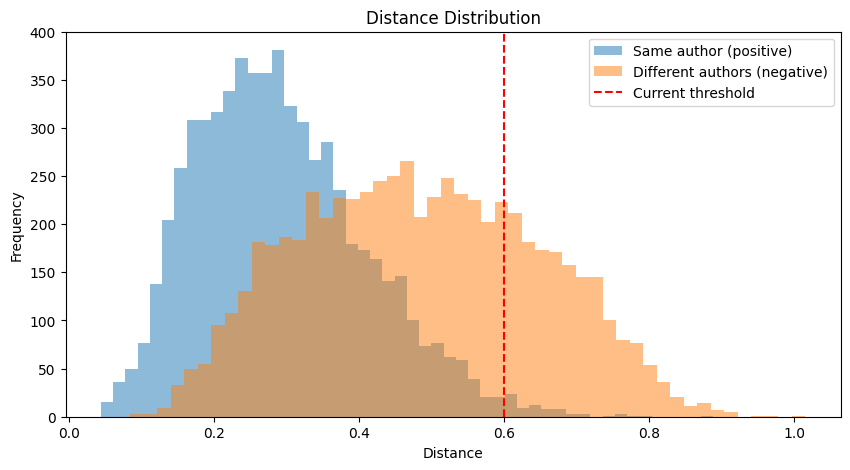

In [ ]:
distances = test_results['distances']
y_true = test_results['y_true']

pos_distances = distances[y_true == 1]
neg_distances = distances[y_true == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, label='Same author (positive)')
plt.hist(neg_distances, bins=50, alpha=0.5, label='Different authors (negative)')
plt.axvline(x=0.6, color='r', linestyle='--', label='Current threshold')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distance Distribution')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, 1 - (distances / distances.max()))
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx] * distances.max()

logger.info(f"\nOptimal threshold: {optimal_threshold:.4f}")

INFO - 
Optimal threshold: 0.5929


In [ ]:
from src.datasets import DataGenerator

In [ ]:
test_gen = DataGenerator(
    data=subset['test'].data,
    shuffle=False
)

In [ ]:
all_embeddings: list[np.ndarray] = []
all_author_ids: list[np.ndarray] = []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    emb = cnn_evaluator.embedding_model.predict(X, verbose=0)
    all_embeddings.append(emb)
    all_author_ids.append(y)

embeddings = np.concatenate(all_embeddings, axis=0)   # (N, D)
author_ids = np.concatenate(all_author_ids, axis=0)   # (N,)

In [ ]:
from collections import defaultdict

def build_gallery(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
) -> dict[int, np.ndarray]:

    by_author: dict[int, list[np.ndarray]] = defaultdict(list)

    for emb, author_id in zip(embeddings, author_ids):
        by_author[int(author_id)].append(emb)

    gallery = {
        author_id: np.mean(np.stack(author_embs), axis=0)
        for author_id, author_embs in by_author.items()
    }

    return gallery

In [ ]:
gallery = build_gallery(embeddings, author_ids)

In [ ]:
def identify_author(
    author_embeddings: np.ndarray,
    gallery: dict[int, np.ndarray],
) -> dict[str, any]:

    scores: dict[int, float] = {}

    for author_id, gallery_emb in gallery.items():
        distances = np.linalg.norm(author_embeddings - gallery_emb, axis=1)
        scores[author_id] = float(distances.mean())

    pred_author = min(scores, key=scores.get)

    return {
        "pred_author_id": pred_author,
        "scores": scores,
        "mean_distance": scores[pred_author],
    }

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_identification(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    gallery: dict[int, np.ndarray],
    min_patches: int = 3,
) -> dict[str, any]:

    y_true: list[int] = []
    y_pred: list[int] = []
    details: list[dict[str, any]] = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        author_embs = embeddings[idx]
        res = identify_author(author_embs, gallery)

        y_true.append(author_id)
        y_pred.append(res["pred_author_id"])

        details.append({
            "true_author_id": author_id,
            "pred_author_id": res["pred_author_id"],
            "correct": author_id == res["pred_author_id"],
            "mean_distance": res["mean_distance"],
        })

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "num_authors": len(y_true),
        "details": details,
    }

In [ ]:
import pandas as pd

def identification_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["true_author_id"] = df["true_author_id"].astype(int)
    df["pred_author_id"] = df["pred_author_id"].astype(int)
    df["correct"] = df["correct"].astype(bool)
    df["mean_distance"] = df["mean_distance"].astype(float)

    return df

In [ ]:
def extract_identification_summary(res: dict) -> dict[str, float | int]:
    """
    Extract high-level identification metrics.
    """
    return {
        "accuracy": res["accuracy"],
        "num_authors": res["num_authors"],
    }

In [ ]:
identification_results = evaluate_identification(
    embeddings,
    author_ids,
    gallery,
)

In [ ]:
res = identification_results_to_df(identification_results)
summary = extract_identification_summary(identification_results)

In [ ]:
logger.info(f"Identification summary: {summary}")

INFO - Identification summary: {'accuracy': 1.0, 'num_authors': 100}


In [ ]:
res

,true_author_id,pred_author_id,correct,mean_distance
0,0,0,True,0.144635
1,1,1,True,0.168354
2,2,2,True,0.160292
3,3,3,True,0.244917
4,4,4,True,0.226033
...,...,...,...,...
95,95,95,True,0.197329
96,96,96,True,0.196140
97,97,97,True,0.165420
98,98,98,True,0.212138


In [ ]:
def voting_for_author(
    embeddings: np.ndarray,
    distance_threshold: float,
) -> dict[str, any]:

    votes_same, votes_diff = 0, 0
    distances = []

    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            d = np.linalg.norm(embeddings[i] - embeddings[j])
            distances.append(d)

            if d < distance_threshold:
                votes_same += 1
            else:
                votes_diff += 1

    total = votes_same + votes_diff

    return {
        "votes_same": votes_same,
        "votes_diff": votes_diff,
        "confidence": votes_same / total if total > 0 else 0.0,
        "mean_distance": float(np.mean(distances)),
        "std_distance": float(np.std(distances)),
        "num_pairs": total,
    }

In [ ]:
def evaluate_voting(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    distance_threshold: float,
    min_patches: int = 3,
) -> dict[str, any]:

    details = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        res = voting_for_author(
            embeddings[idx],
            distance_threshold,
        )

        details.append({
            "author_id": author_id,
            **res,
        })

    return {
        "num_authors": len(details),
        "details": details,
    }

In [ ]:
import pandas as pd

def voting_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["author_id"] = df["author_id"].astype(int)
    df["votes_same"] = df["votes_same"].astype(int)
    df["votes_diff"] = df["votes_diff"].astype(int)
    df["confidence"] = df["confidence"].astype(float)
    df["mean_distance"] = df["mean_distance"].astype(float)
    df["std_distance"] = df["std_distance"].astype(float)
    df["num_pairs"] = df["num_pairs"].astype(int)

    return df

In [ ]:
voting_results = evaluate_voting(
    embeddings,
    author_ids,
    distance_threshold=0.57
)

In [ ]:
v_results = voting_results_to_df(voting_results)

In [ ]:
v_results

,author_id,votes_same,votes_diff,confidence,mean_distance,std_distance,num_pairs
0,0,5778,0,1.000000,0.203721,0.071117,5778
1,1,7502,1,0.999867,0.237453,0.079947,7503
2,2,8346,169,0.980153,0.228701,0.116683,8515
3,3,8825,355,0.961329,0.342887,0.119808,9180
4,4,7867,134,0.983252,0.316586,0.109997,8001
...,...,...,...,...,...,...,...
95,95,6539,16,0.997559,0.278524,0.088328,6555
96,96,7466,160,0.979019,0.279298,0.118180,7626
97,97,8113,143,0.982679,0.231823,0.124169,8256
98,98,8163,222,0.973524,0.300490,0.119464,8385


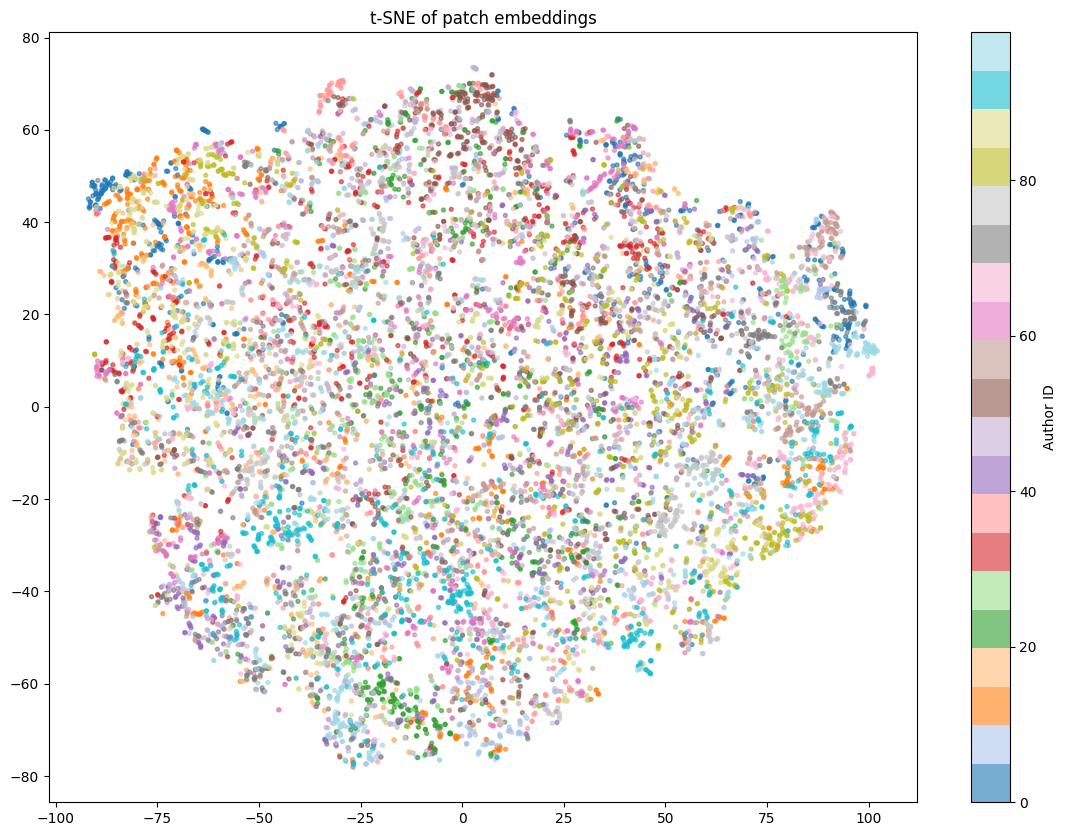

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
)

emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 10))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=author_ids,
    cmap="tab20",
    s=8,
    alpha=0.6,
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of patch embeddings")
plt.show()

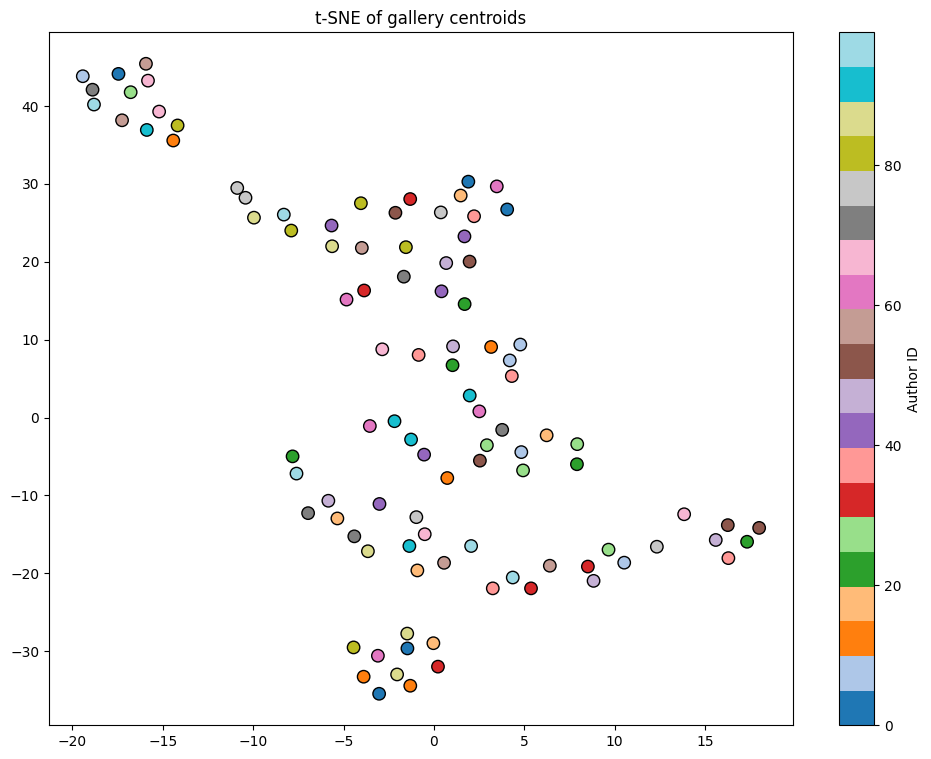

In [ ]:
gallery_embeddings = np.stack(list(gallery.values()))
gallery_author_ids = np.array(list(gallery.keys()))

tsne = TSNE(
    n_components=2,
    perplexity=10,
    max_iter=1000,
    random_state=42,
)

gallery_2d = tsne.fit_transform(gallery_embeddings)

plt.figure(figsize=(12, 9))
plt.scatter(
    gallery_2d[:, 0],
    gallery_2d[:, 1],
    c=gallery_author_ids,
    cmap="tab20",
    s=80,
    edgecolors="black",
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of gallery centroids")
plt.show()